In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import random
import os
import numpy as np

from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
from PIL import Image

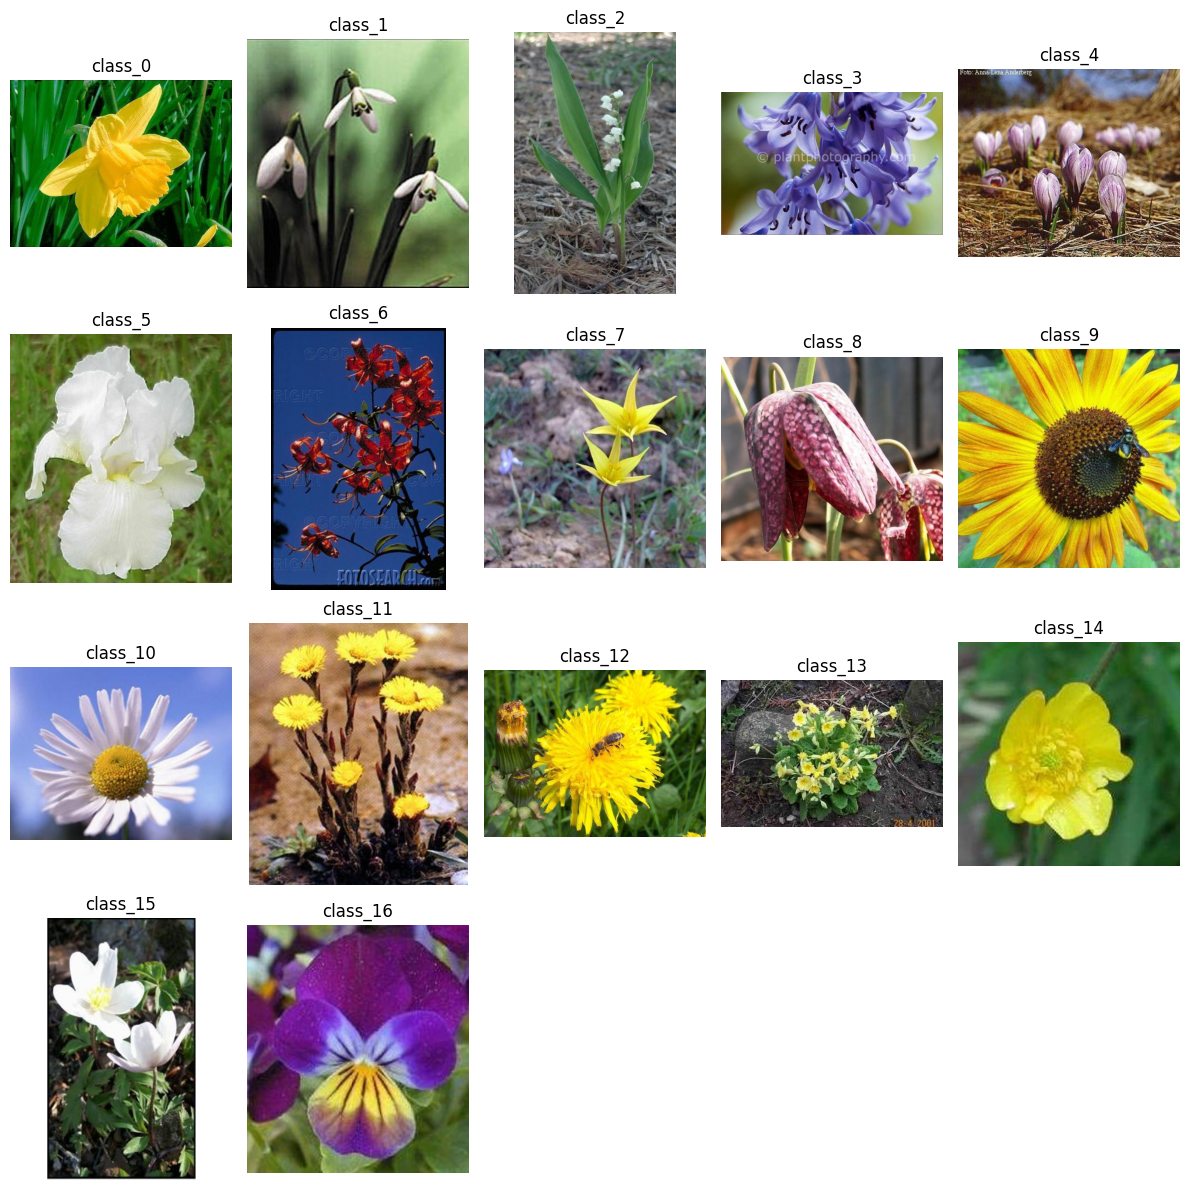

In [ ]:
data_dir = 'sorted_dataset'

class_dirs = os.listdir(data_dir)
class_dirs= sorted(class_dirs, key=lambda x: int(x.split('_')[1]))

plt.figure(figsize=(12, 12))

for i, class_dir in enumerate(class_dirs):
    class_path = os.path.join(data_dir, class_dir)
    
    class_images = os.listdir(class_path)
    
    img_path = os.path.join(class_path, class_images[0])
    image = Image.open(img_path)
    
    plt.subplot(4, 5, i + 1)
    plt.imshow(image)
    plt.title(class_dir)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
batch_size = 32
epochs = 10
learning_rate = 0.00005
val_split = 0.15
test_split = 0.15
image_size = 224
torch.set_default_dtype(torch.float32)

In [219]:
train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomGrayscale(p=0.1),
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)),
])

test_val_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
dataset = datasets.ImageFolder(root=data_dir)  
num_classes = len(dataset.classes)

train_size = int((1 - val_split - test_split) * len(dataset))
val_size = int(val_split * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

In [221]:
train_dataset.dataset = datasets.ImageFolder(root=data_dir, transform=train_transform)
val_dataset.dataset = datasets.ImageFolder(root=data_dir, transform=test_val_transform)
test_dataset.dataset = datasets.ImageFolder(root=data_dir, transform=test_val_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [222]:
model = models.resnet18(pretrained=True)

for param in model.parameters():
    param.requires_grad = False  

in_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, num_classes)
)

for param in model.fc.parameters():
    param.requires_grad = True  

model = model.to(torch.device("mps"))


/Users/xd/Desktop/nsu_2course/2_sem/AI/venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/xd/Desktop/nsu_2course/2_sem/AI/venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [223]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)

In [ ]:
for images, labels in train_loader:
    print(f"Image dtype: {images.dtype}, Label dtype: {labels.dtype}")
    break

Image dtype: torch.float32, Label dtype: torch.int64


In [ ]:
def evaluate(model, loader, criterion, device, isTest):
    class_names = dataset.classes 
    device = torch.device("mps")
    model.eval()
    correct, total = 0, 0
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device).float(), labels.to(device).long()
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy()) 
    
    acc = 100.0 * correct / total
    precision = precision_score(all_labels, all_preds, average='weighted') 
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')

    
    if isTest:
        cm = confusion_matrix(all_labels, all_preds)
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")
        plt.title("Confusion Matrix")
        plt.show()
    return acc, total_loss, precision, recall, f1

In [ ]:
for images, labels in train_loader:
    print(f"Image dtype: {images.dtype}, Label dtype: {labels.dtype}")
    break

Image dtype: torch.float32, Label dtype: torch.int64


In [ ]:
train_accuracy_arr = []
val_accuracy_arr = []
train_loss_arr = []
val_loss_arr = []
val_precisson_arr = []
val_recall_arr = []
val_f1_arr = []

def train(model, train_loader, val_loader, criterion, optimizer, epochs):
    device = torch.device("mps")
    model.to(device)
    model.train()
    
    for epoch in range(epochs):
        running_loss = 0.0
        correct, total = 0, 0
        
        for images, labels in train_loader:
            images, labels = images.to(device).float(), labels.to(device).long()
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        train_acc = 100.0 * correct / total
        val_acc, val_loss, val_precission, val_recall, val_f1 = evaluate(model, val_loader, criterion, device, 0)

        train_accuracy_arr.append(train_acc)
        val_accuracy_arr.append(val_acc)
        train_loss_arr.append(running_loss/len(train_loader))
        val_loss_arr.append(val_loss/len(train_loader))
        val_precisson_arr.append(val_precission)
        val_recall_arr.append(val_recall)
        val_f1_arr.append(val_f1)
        
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {running_loss/len(train_loader):.4f},  Val Loss: {val_loss/len(train_loader):.4f}, Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%, Precisson: {val_precission:.2f}, Recall: {val_recall:.2f}, F1: {val_f1:.2f}")


In [232]:
for param in model.parameters():
    param.requires_grad = True

train(model, train_loader, val_loader, criterion, optimizer, epochs)

Epoch 1/10, Train Loss: 2.4938,  Val Loss: 0.3348, Train Acc: 22.50%, Val Acc: 68.63%, Precisson: 0.77, Recall: 0.69, F1: 0.69
Epoch 2/10, Train Loss: 0.8412,  Val Loss: 0.0956, Train Acc: 76.55%, Val Acc: 86.76%, Precisson: 0.89, Recall: 0.87, F1: 0.87
Epoch 3/10, Train Loss: 0.4717,  Val Loss: 0.0606, Train Acc: 86.01%, Val Acc: 90.20%, Precisson: 0.93, Recall: 0.90, F1: 0.91
Epoch 4/10, Train Loss: 0.2414,  Val Loss: 0.0619, Train Acc: 92.74%, Val Acc: 89.71%, Precisson: 0.94, Recall: 0.90, F1: 0.90
Epoch 5/10, Train Loss: 0.2313,  Val Loss: 0.0610, Train Acc: 92.95%, Val Acc: 90.69%, Precisson: 0.95, Recall: 0.91, F1: 0.91
Epoch 6/10, Train Loss: 0.1638,  Val Loss: 0.0517, Train Acc: 94.95%, Val Acc: 90.69%, Precisson: 0.95, Recall: 0.91, F1: 0.91
Epoch 7/10, Train Loss: 0.1783,  Val Loss: 0.0346, Train Acc: 93.80%, Val Acc: 95.59%, Precisson: 0.96, Recall: 0.96, F1: 0.95
Epoch 8/10, Train Loss: 0.1197,  Val Loss: 0.0234, Train Acc: 95.58%, Val Acc: 97.06%, Precisson: 0.97, Recall:

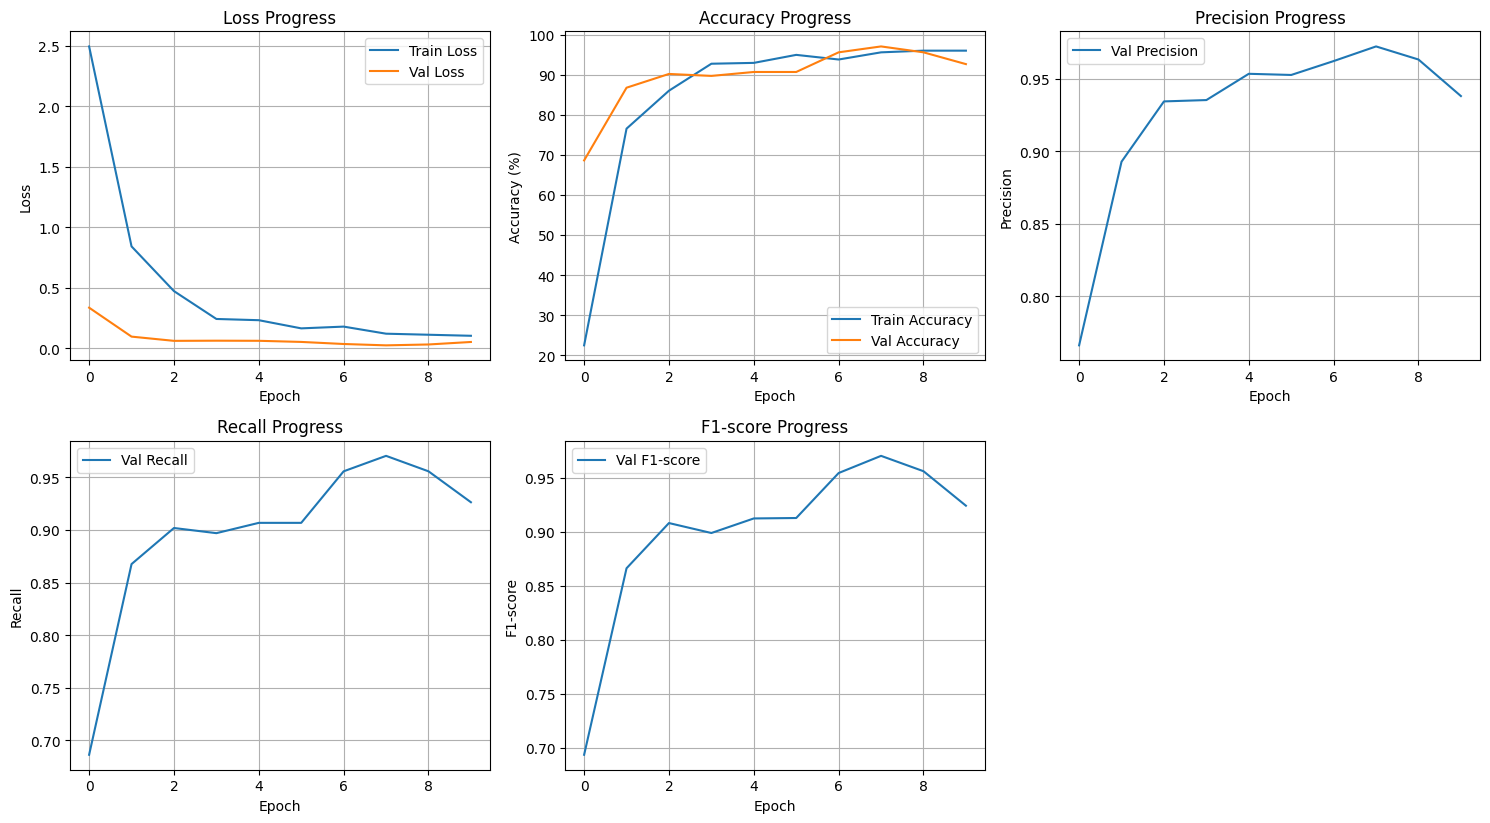

In [ ]:
plt.figure(figsize=(15, 12))

plt.subplot(3, 3, 1)
plt.plot(train_loss_arr, label='Train Loss')
plt.plot(val_loss_arr, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.title('Loss Progress')

plt.subplot(3, 3, 2)
plt.plot(train_accuracy_arr, label='Train Accuracy')
plt.plot(val_accuracy_arr, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.title('Accuracy Progress')

plt.subplot(3, 3, 3)
plt.plot(val_precisson_arr, label='Val Precision')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)
plt.title('Precision Progress')

plt.subplot(3, 3, 4)
plt.plot(val_recall_arr, label='Val Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)
plt.title('Recall Progress')


plt.subplot(3, 3, 5)
plt.plot(val_f1_arr, label='Val F1-score')
plt.xlabel('Epoch')
plt.ylabel('F1-score')
plt.legend()
plt.grid(True)
plt.title('F1-score Progress')

plt.tight_layout()
plt.show()


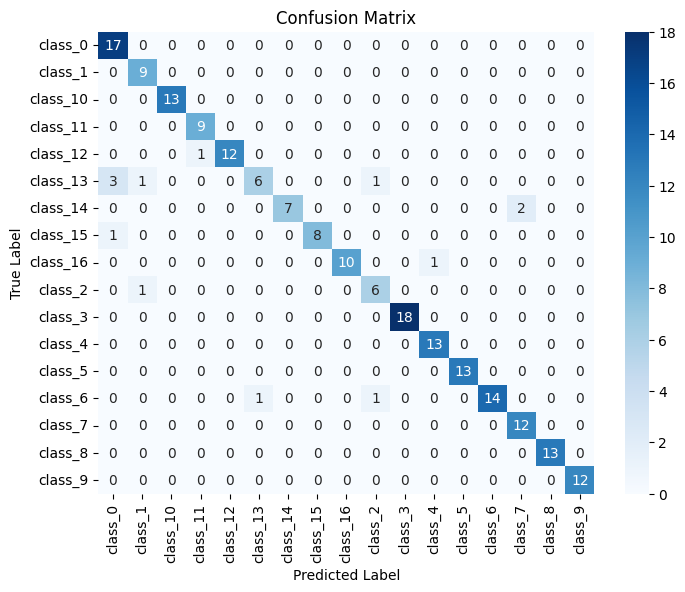

Test Accuracy: 93.66%


In [235]:
isTrain = 1
dev = torch.device("mps")
test_acc, _, _, _, _ = evaluate(model, test_loader, criterion, dev, isTrain)
print(f"Test Accuracy: {test_acc:.2f}%")

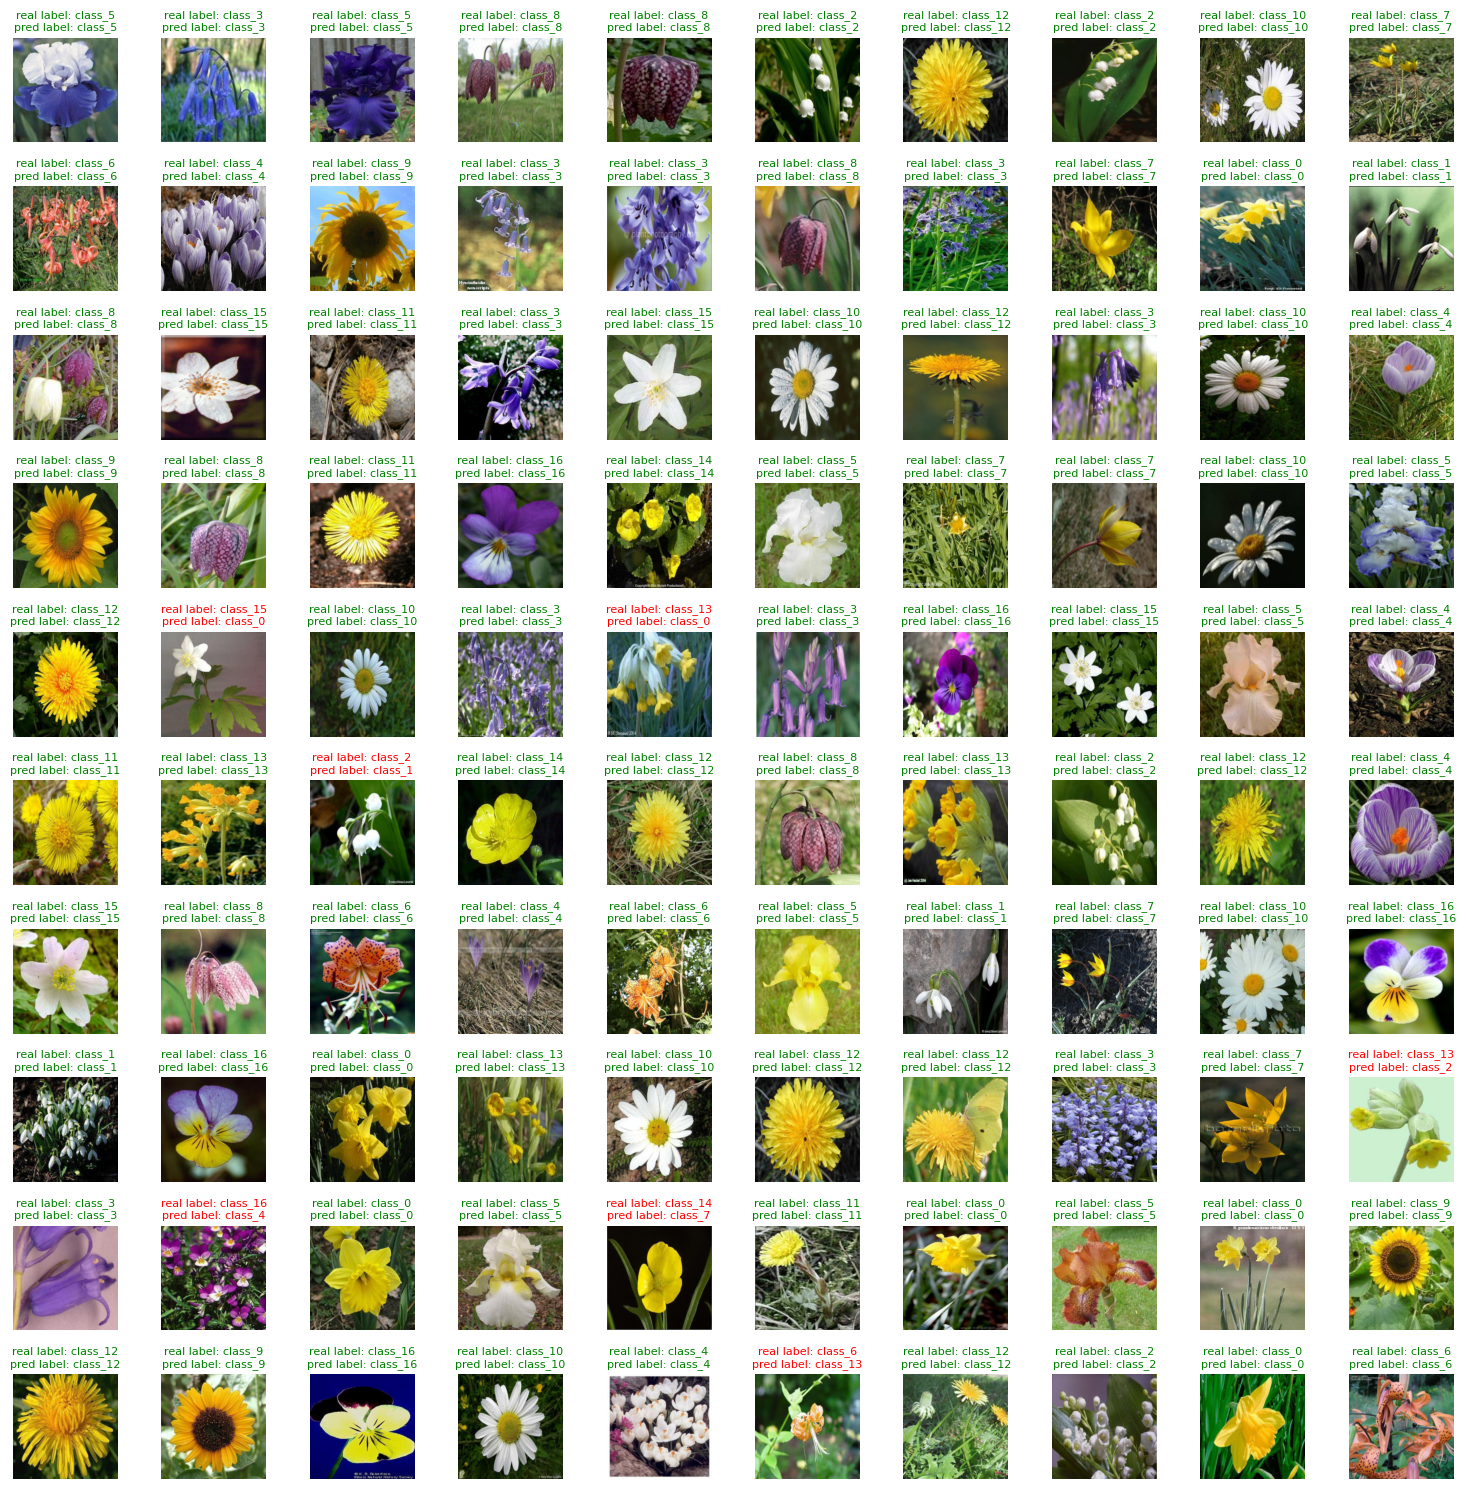

In [ ]:
def visualize_predictions(model, loader, class_names, device, num_images=100):
    device = torch.device("mps")
    model.eval()
    images_list = []
    labels_list = []
    preds_list = []

    # all imgs from test_loader
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)

            images_list.extend(images.cpu())
            labels_list.extend(labels.cpu().numpy())
            preds_list.extend(predicted.cpu().numpy())

    #   take 100 images by random
    indices = random.sample(range(len(images_list)), min(num_images, len(images_list)))
    selected_images = [images_list[i] for i in indices]
    selected_labels = [labels_list[i] for i in indices]
    selected_preds = [preds_list[i] for i in indices]

    #   10x10 net
    _, axes = plt.subplots(10, 10, figsize=(15, 15))
    axes = axes.flatten()

    for i in range(len(selected_images)):
        img = selected_images[i].numpy().transpose((1, 2, 0))  #    (C, H, W) → (H, W, C)
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean  #   denoralization
        img = np.clip(img, 0, 1)  # pix values now: 0-1

        true_label = class_names[selected_labels[i]]
        pred_label = class_names[selected_preds[i]]
        color = "green" if true_label == pred_label else "red" 

        axes[i].imshow(img)
        axes[i].set_title(f"real label: {true_label}\npred label: {pred_label}", color=color, fontsize=8)
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

class_names = dataset.classes

visualize_predictions(model, test_loader, class_names, device="mps", num_images=100)
